In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install transformers datasets torch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 35.7 MB/s eta 0:00:00:00:0100:01
  Attempting u

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. LOAD DATA FUNCTION
def load_data(file_path, label_code):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
        return pd.DataFrame({'text': lines, 'label': label_code})
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()

# 2. LOAD ALL 5 EMOTION FILES
# (Using the paths from your 'normalised-training-data' folder)
base_path = "/kaggle/input/normalised-training-data/"

df_joy = load_data(base_path + "normalized_td_joy.txt", 0)
df_sad = load_data(base_path + "normalized_td_sadness.txt", 1)
df_sarc = load_data(base_path + "normalized_td_sarcasm.txt", 2)
df_ang = load_data(base_path + "training_data_anger.txt", 3)
df_neu = load_data(base_path + "training_data_neutral.txt", 4)

# 3. COMBINE INTO ONE BIG DATASET
df_total = pd.concat([df_joy, df_sad, df_sarc, df_ang, df_neu], axis=0)
print(f"✅ Total Data Loaded: {len(df_total)} sentences")

# 4. THE 80/20 SPLIT (STRATIFIED)
# stratify=df_total['label'] ensures the Test Set has exactly 20% of EACH emotion
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_total['text'].astype(str).tolist(),
    df_total['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_total['label']
)

print(f"Training Set: {len(train_texts)} (80%)")
print(f"Testing Set:  {len(test_texts)} (20%)")

✅ Total Data Loaded: 5605 sentences
Training Set: 4484 (80%)
Testing Set:  1121 (20%)


In [6]:
import torch
from transformers import XLMRobertaTokenizer
from torch.utils.data import Dataset

# 1. DOWNLOAD TOKENIZER
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

# 2. DEFINE DATASET CLASS
class RomanUrduDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 3. CREATE DATASETS
train_dataset = RomanUrduDataset(train_texts, train_labels, tokenizer)
test_dataset = RomanUrduDataset(test_texts, test_labels, tokenizer)
print("✅ Datasets Ready.")

✅ Datasets Ready.


In [7]:
from transformers import XLMRobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import shutil
import os

# Clean up old logs to save space
if os.path.exists("./results"): shutil.rmtree("./results")

# 1. LOAD MODEL
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=5)

# 2. METRICS
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# 3. SETTINGS
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,              # 4 Epochs for good balance
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,              # Optimal LR for XLM-R
    fp16=True,                       # Turbo mode
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",           # Check accuracy every epoch
    save_strategy="epoch",
    save_total_limit=1,              # Saves disk space
    load_best_model_at_end=True,
    report_to="none"
)

# 4. TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# 5. START TRAINING
print("🚀 Starting Training on 80% Data...")
trainer.train()
print("✅ Training Complete.")

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Starting Training on 80% Data...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.609900,1.298496,0.520963,0.522140
2,0.712600,0.588432,0.782337,0.772947
3,0.407400,0.322765,0.878680,0.878199
4,0.299200,0.280936,0.899197,0.898586


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


✅ Training Complete.


Running predictions on Test Set...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



FINAL RESULTS (80/20 Split)
              precision    recall  f1-score   support

         Joy       0.85      0.93      0.89       306
     Sadness       0.86      0.77      0.82       222
     Sarcasm       0.94      0.90      0.92       186
       Anger       0.96      0.93      0.94       201
     Neutral       0.93      0.96      0.95       206

    accuracy                           0.90      1121
   macro avg       0.91      0.90      0.90      1121
weighted avg       0.90      0.90      0.90      1121



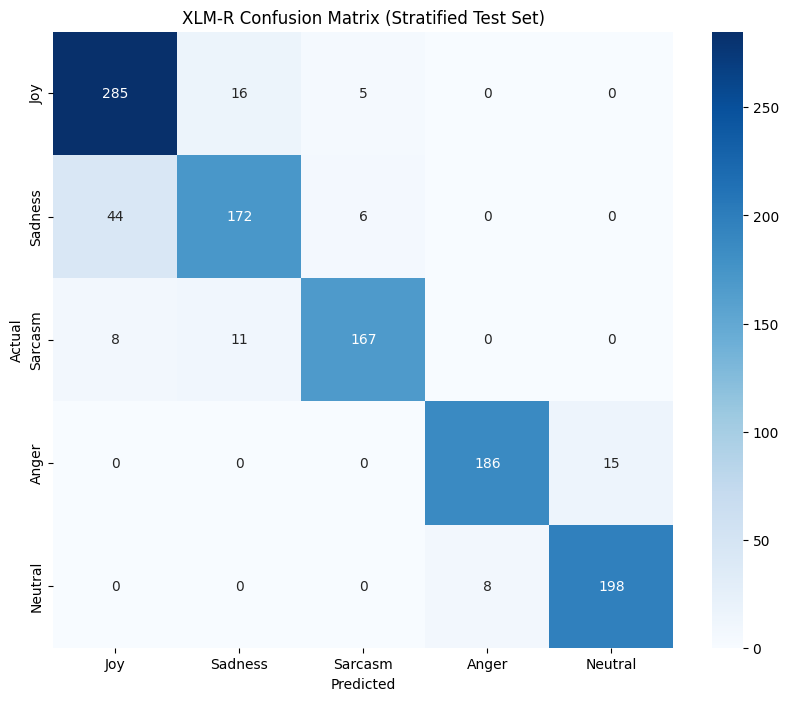

✅ Model saved locally.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. PREDICT ON 20% TEST SET
print("Running predictions on Test Set...")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

# 2. GENERATE REPORT
label_names = ["Joy", "Sadness", "Sarcasm", "Anger", "Neutral"]
print("\n" + "="*50)
print("FINAL RESULTS (80/20 Split)")
print("="*50)
print(classification_report(test_labels, preds, target_names=label_names))

# 3. SAVE CONFUSION MATRIX
cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title("XLM-R Confusion Matrix (Stratified Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("/kaggle/working/final_confusion_matrix.png")
plt.show()

# 4. SAVE MODEL
model.save_pretrained("/kaggle/working/xlm_model_final")
tokenizer.save_pretrained("/kaggle/working/xlm_model_final")
print("✅ Model saved locally.")

In [9]:
import shutil
shutil.make_archive("xlm_emotion_model", 'zip', "/kaggle/working/xlm_model_final")
print("🎉 Zip created! Download 'xlm_emotion_model.zip' from Output.")

🎉 Zip created! Download 'xlm_emotion_model.zip' from Output.
